# Phase 2: Feature Engineering & Target Definition

Converting the raw dataset into ML-ready features and target variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import load_all_daily_prices, load_splits, BASE_PATH
from utils.plot_helpers import setup_plotting_style, CSE_COLORS
from utils.data_cleaning import clean_and_prepare_data
from utils.features import generate_technical_features
from utils.targets import generate_targets

setup_plotting_style()
pd.set_option('display.max_columns', 100)


## 1. Data Loading

In [2]:
# Load raw data
df_raw = load_all_daily_prices()
df_splits = load_splits(BASE_PATH)
print(f"Raw data shape: {df_raw.shape}")


📦 Loading cached data from consolidated_daily_prices.parquet...
   ✅ Loaded 1,270,556 rows, 395 companies


Loading splits: 100%|██████████| 17/17 [00:00<00:00, 138.90it/s]

Raw data shape: (1270556, 13)


## 2. Data Cleaning & Calendar Alignment
Focusing on the Modern Era (2001-2025) and applying stock split adjustments.

Starting data cleaning. Initial shape: (1270556, 13)
Filtered to >= 2001. Shape: (1124883, 13)
Removed duplicates. Shape: (1047658, 13)
Aligning trading calendars and forward-filling missing days...
Adjusting historical prices for stock splits...
Data cleaning complete. Final shape: (1373967, 14)


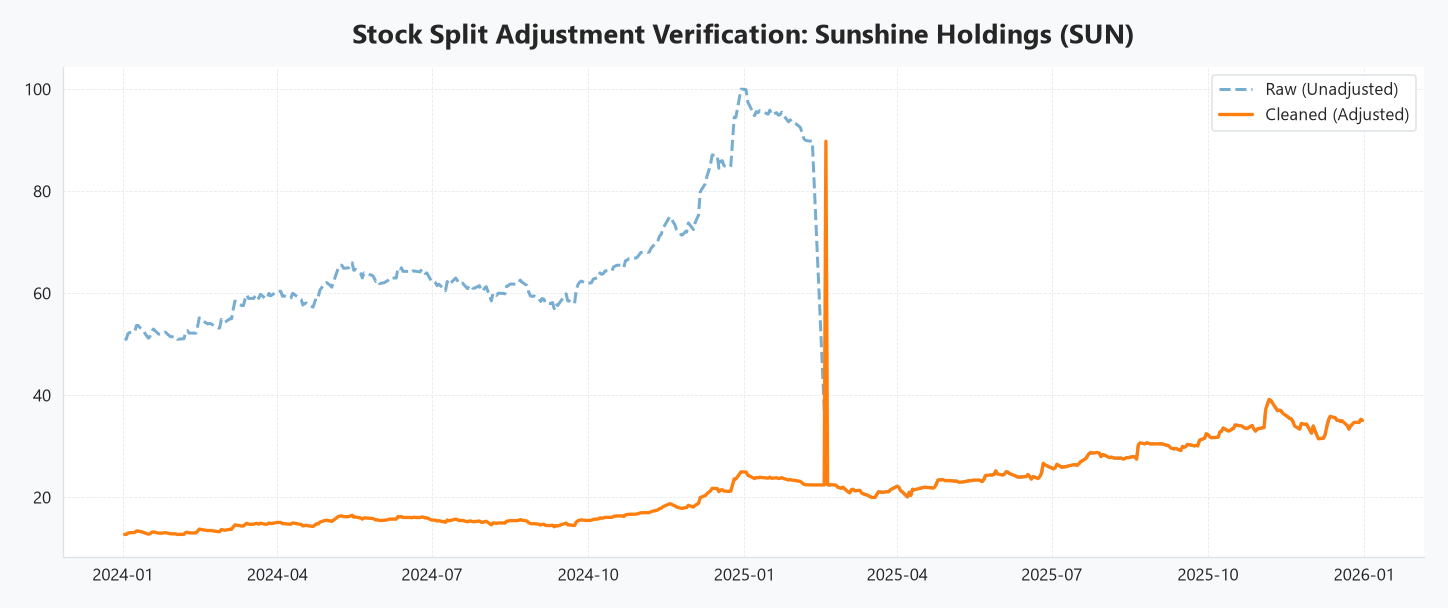

In [3]:
# Clean the data
df_clean = clean_and_prepare_data(df_raw, df_splits, start_year=2001)

# Verify stock split adjustment using an example company if possible (e.g. SUN)
# Sunshine Holdings (SUN.N0000) split 1 to 4 on 2025-02-18
sun_raw = df_raw[(df_raw['CompanyCode'] == 'SUN') & (df_raw['Date'].dt.year >= 2024)]
sun_clean = df_clean[(df_clean['CompanyCode'] == 'SUN') & (df_clean['Date'].dt.year >= 2024)]

if not sun_raw.empty and not sun_clean.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(sun_raw['Date'], sun_raw['Close'], label='Raw (Unadjusted)', alpha=0.6, linestyle='--')
    ax.plot(sun_clean['Date'], sun_clean['Close'], label='Cleaned (Adjusted)', linewidth=2)
    ax.set_title('Stock Split Adjustment Verification: Sunshine Holdings (SUN)')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 3. Feature Engineering
Generating technical indicators (RSI, MACD, Bollinger Bands, MAs) per stock.

Generating technical features...
Technical features generation complete.


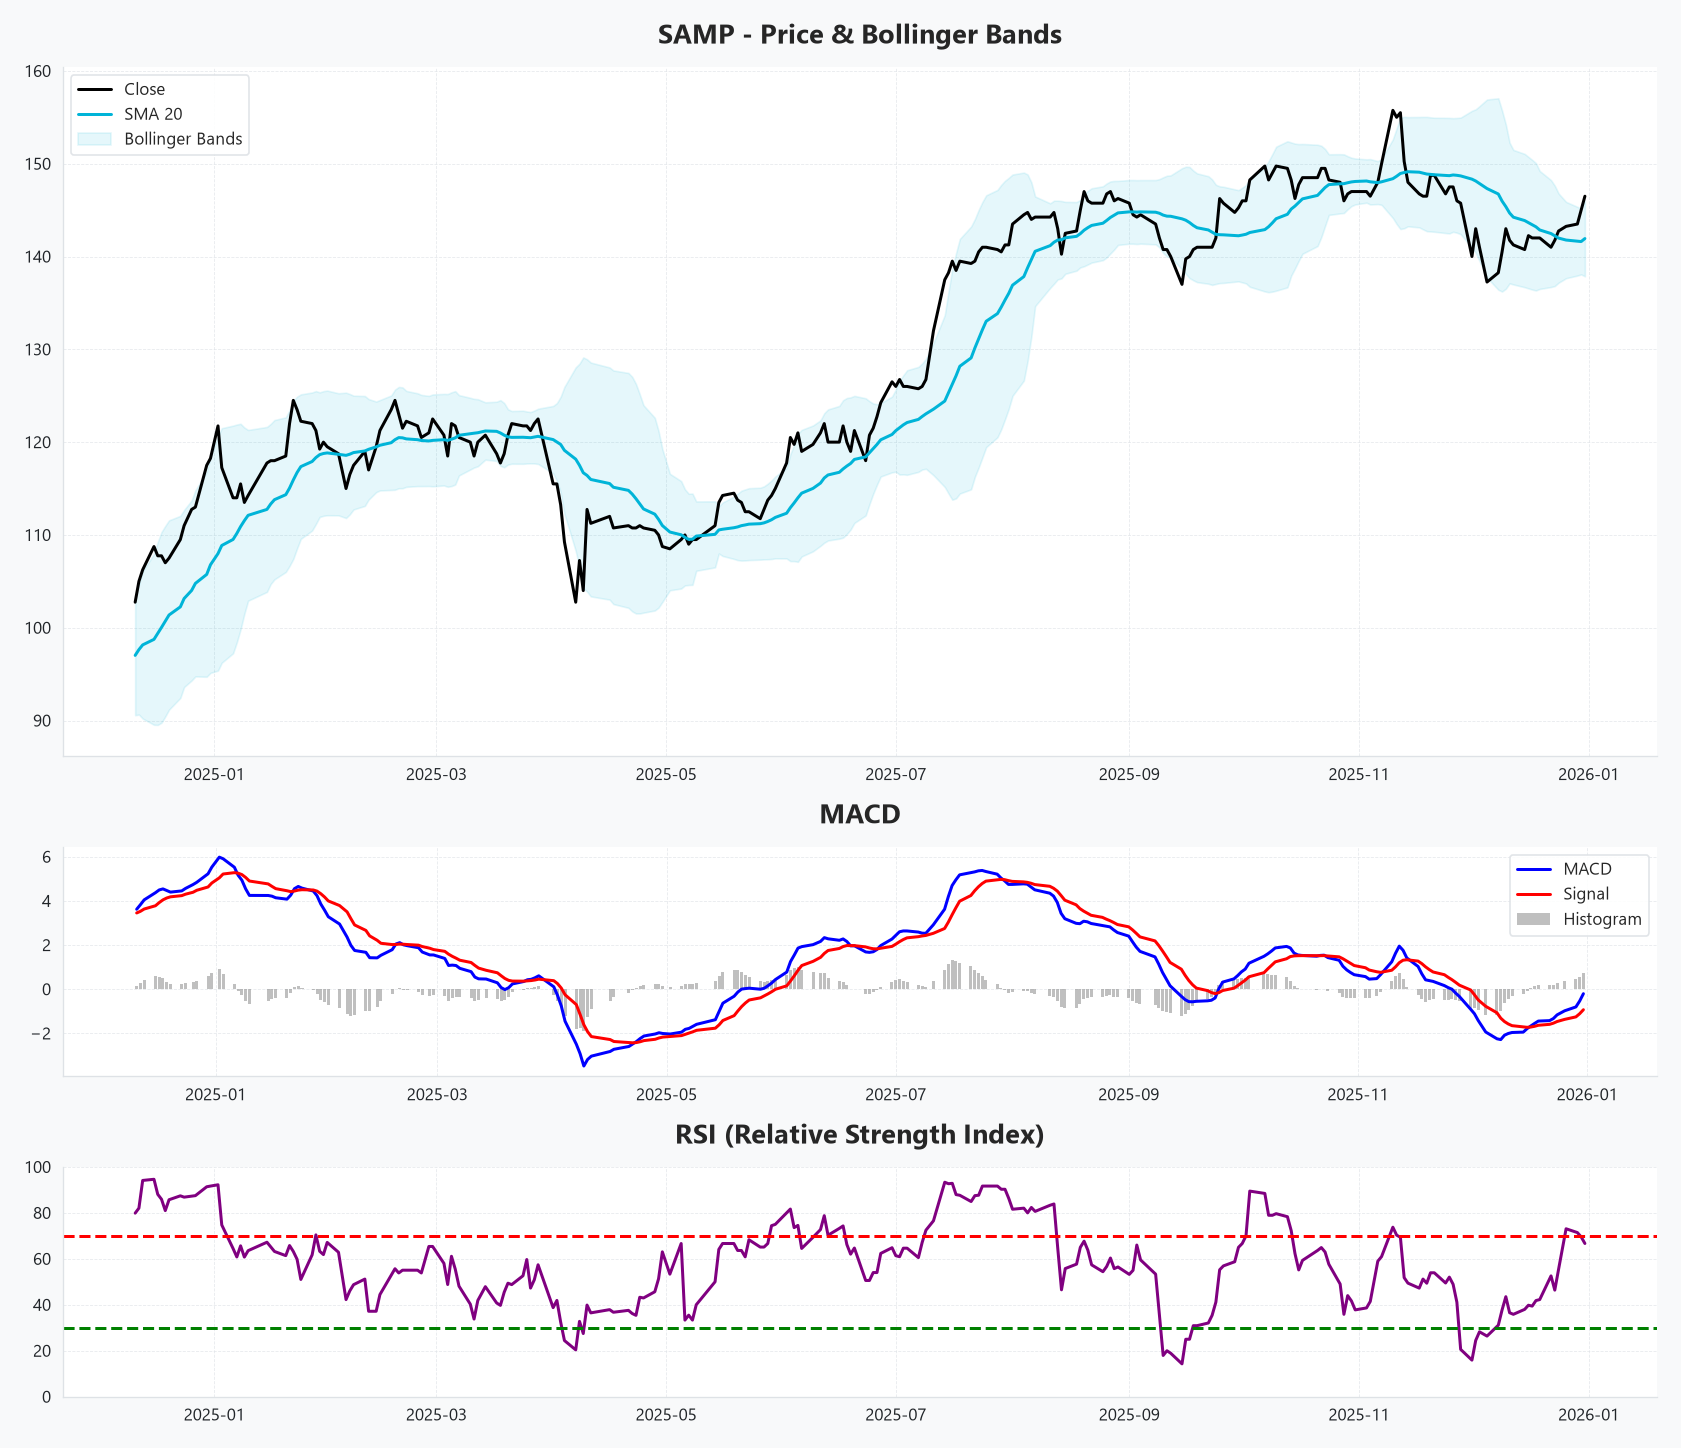

In [4]:
# Generate features
df_features = generate_technical_features(df_clean)

# Visualize features for a sample stock
sample_stock = df_features['CompanyCode'].value_counts().index[0]  # Get most traded stock
sample = df_features[df_features['CompanyCode'] == sample_stock].tail(252).set_index('Date') # Last year

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [3, 1, 1]})

# Price and Bollinger Bands
ax1.plot(sample.index, sample['Close'], color='black', label='Close')
ax1.plot(sample.index, sample['SMA_20'], color=CSE_COLORS['teal'], label='SMA 20')
ax1.fill_between(sample.index, sample['BB_Lower'], sample['BB_Upper'], color=CSE_COLORS['teal'], alpha=0.1, label='Bollinger Bands')
ax1.set_title(f'{sample_stock} - Price & Bollinger Bands')
ax1.legend()

# MACD
ax2.plot(sample.index, sample['MACD'], color='blue', label='MACD')
ax2.plot(sample.index, sample['MACD_Signal'], color='red', label='Signal')
ax2.bar(sample.index, sample['MACD_Hist'], color='gray', alpha=0.5, label='Histogram')
ax2.set_title('MACD')
ax2.legend()

# RSI
ax3.plot(sample.index, sample['RSI_14'], color='purple', label='RSI 14')
ax3.axhline(70, color='red', linestyle='--')
ax3.axhline(30, color='green', linestyle='--')
ax3.set_title('RSI (Relative Strength Index)')
ax3.set_ylim(0, 100)

plt.tight_layout()
plt.show()


## 4. Target Variable Definition
Generating Short, Medium, and Long-Term forward returns and binary classification labels.

Generating target variables...
Target variables generation complete.


AttributeError: Rectangle.set() got an unexpected keyword argument 'range'

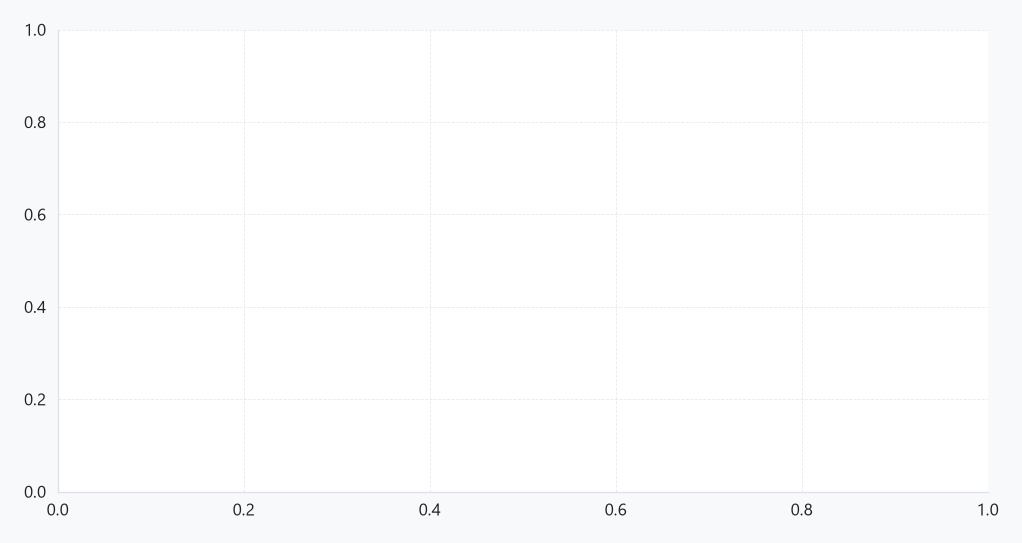

In [5]:
# Generate targets
df_final = generate_targets(df_features)

# Target Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_final['Target_Return_3M'].dropna(), bins=100, range=(-1, 2), kde=True, color=CSE_COLORS['primary'])
plt.axvline(0, color='red', linestyle='--')
plt.axvline(0.05, color='green', linestyle='--', label='5% Uptrend Threshold')
plt.title('Distribution of 3-Month Forward Returns')
plt.legend()
plt.tight_layout()
plt.show()

print("Target Class Balance (3M Uptrend > 5%):")
print(df_final['Is_Uptrend_3M'].value_counts(normalize=True) * 100)


## 5. Feature-Target Correlation
Which features are most correlated with our 3-month forward returns?

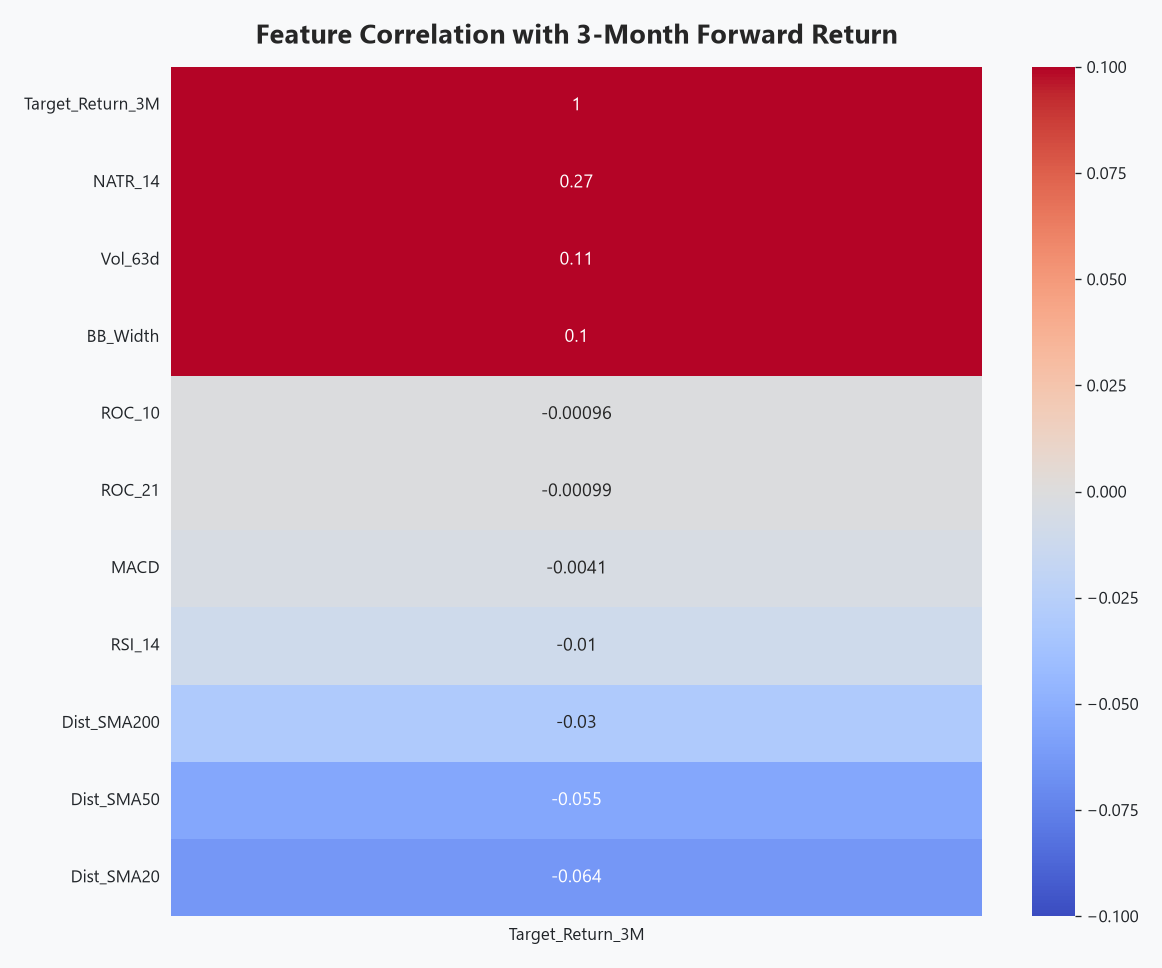

In [6]:
corr_features = ['Dist_SMA20', 'Dist_SMA50', 'Dist_SMA200', 'RSI_14', 'MACD', 
                 'BB_Width', 'NATR_14', 'ROC_10', 'ROC_21', 'Vol_63d', 'Target_Return_3M']

corr = df_final[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr[['Target_Return_3M']].sort_values(by='Target_Return_3M', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)
plt.title('Feature Correlation with 3-Month Forward Return')
plt.tight_layout()
plt.show()


## 6. Save Dataset
Exporting the final ML-ready dataset for Phase 3.

In [7]:
import os
out_path = os.path.join(BASE_PATH, 'engineered_features.parquet')
df_final.to_parquet(out_path, index=False)
print(f"Successfully saved engineered dataset to: {out_path}")
print(f"Final shape: {df_final.shape}")


Successfully saved engineered dataset to: c:\Users\HP\Documents\Stock_pulse\Dataset\2025 Q4\engineered_features.parquet
Final shape: (1373967, 49)
